# Agentic Design Patterns: Self-Healing

Welcome to the final pattern constraint of this module: **Self-Healing**.

When agents use tools—specifically code execution tools (like a Python REPL) or external APIs—things will break. A URL might 404, a library might be missing, or the LLM might write syntactically invalid Python.

A self-healing pattern wraps dangerous or unpredictable tool calls in an explicit `try-except` block within the LangGraph architecture. If an error occurs, the actual Python Exception trace is fed **back** into the LLM prompt. The LLM acts as its own debugger, rewriting the code to bypass the error.

---

## 1. Environment Setup

In [1]:
import os
import traceback
from typing import Annotated, TypedDict, List
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

load_dotenv()
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

print("Self-Healing Environment Ready!")

/Users/balamurugan/Documents/bala_github/AgenticAI-LearningPath/.venv/lib/python3.9/site-packages/google/api_core/_python_version_support.py:234: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
/Users/balamurugan/Documents/bala_github/AgenticAI-LearningPath/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/balamurugan/Documents/bala_github/AgenticAI-LearningPath/.venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with cri

Self-Healing Environment Ready!


## 2. Setting Up the Unsafe Dummy Tool
We need a function to represent user-generated code. We'll simply use `exec()`. 

> **SECURITY WARNING:** Using `exec()` in a real environment running LLM-generated code is incredibly dangerous. Always use a sandboxed container (like Docker) or a secure tool framework (like E2B or MultiOn) for code execution.

In [2]:
def unsafe_python_repl(code: str) -> str:
    """Simulates running python code and returning the output or error."""
    try:
        # Create a local namespace so we can grab variables out of it later
        local_vars = {}
        exec(code, globals(), local_vars)
        # For demonstration, we assume the script is meant to define a "result" variable
        if "result" in local_vars:
            return f"Success. Result: {local_vars['result']}"
        else:
            return "Success. No 'result' variable found in local scope."
    except Exception as e:
        # The crucial part: Return the EXACT traceback
        error_trace = traceback.format_exc()
        return f"ERROR:\n{error_trace}"

## 3. Defining State & Pydantic
The LLM needs to explicitly output the code it wants to run.

In [3]:
class PythonCode(BaseModel):
    """The exact Python code to execute."""
    code: str = Field(description="Python code script string. Must define a variable named 'result' containing the final output.")

class HealingState(TypedDict):
    messages: Annotated[List[BaseMessage], lambda a, b: a + b]
    generated_code: str
    execution_output: str
    is_error: bool
    attempts: int

coder_llm = llm.with_structured_output(PythonCode)

## 4. The Agentic Nodes
We have a Coder, and an execution wrapper.

In [4]:
def coder_node(state: HealingState):
    print(f"\n--- CODER (Attempt {state.get('attempts', 0) + 1}) IS WRITING SCRIPT ---")
    system_msg = SystemMessage(
        content="""You are a Python data engineer. Write code to solve the user's problem.
        You must assign the final output to a variable named 'result'.
        If you see previous errors, debug your previous code and rewrite it to fix the issue.
        """
    )
    
    response = coder_llm.invoke([system_msg] + state["messages"])
    
    # Increment attempts
    return {
        "generated_code": response.code,
        "attempts": state.get("attempts", 0) + 1
    }

def execution_node(state: HealingState):
    print("--- RUNNING SCRIPT IN REPL ---")
    code_to_run = state["generated_code"]
    
    output = unsafe_python_repl(code_to_run)
    
    # Determine if it failed based on our string formatting
    is_error = output.startswith("ERROR:")
    
    if is_error:
        print(f"--> CRASH DETECTED. Sending trace back to Coder.\n{output[-100:]}...") # print just end of trace
        feedback_msg = HumanMessage(
            content=f"Your previous code failed. Evaluate this traceback and rewrite the code:\n\nPrevious Code:\n{code_to_run}\n\nTraceback:\n{output}"
        )
    else:
        print("--> EXECUTION SUCCESSFUL.")
        feedback_msg = AIMessage(content=f"Execution complete. Output: {output}")
        
    return {
        "messages": [feedback_msg],
        "execution_output": output,
        "is_error": is_error
    }

def should_heal(state: HealingState):
    if state["is_error"] and state.get("attempts", 0) < 3:
        # Loop back to coder to self-heal
        return "coder"
    
    # Either it succeeded, or we hit max attempts
    return END

## 5. Compile and Visualize

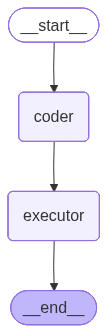

In [5]:
builder = StateGraph(HealingState)

builder.add_node("coder", coder_node)
builder.add_node("executor", execution_node)

builder.add_edge(START, "coder")
builder.add_edge("coder", "executor")
builder.add_conditional_edges("executor", should_heal)

app = builder.compile()

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph visualization failed.")

## 6. Testing the Self-Healing Loop
Let's assign a prompt where we intentionally try to break it by asking for an import package that doesn't exist, and see how the LLM reacts when it gets a `ModuleNotFoundError`.

In [6]:
# This prompt tasks the LLM with something that might cause a bug depending on how it approaches it
query = "Write a script to open a file called 'made_up_file.txt', read its contents into a string, and return it. Do not use try/except in your script."

initial_state = {
    "messages": [HumanMessage(content=query)],
    "attempts": 0
}

for chunk in app.stream(initial_state, stream_mode="updates"):
    if "coder" in chunk:
        print(f"-> Code Drafted (Length: {len(chunk['coder']['generated_code'])} chars)")
    elif "executor" in chunk:
        if not chunk["executor"]["is_error"]:
           print(f"\n*** FINAL STATUS: Success ***\nOutput: {chunk['executor']['execution_output']}")
        elif chunk["executor"]["is_error"] and chunk["executor"].get("attempts", 0) >= 3:
           print(f"\n*** FINAL STATUS: Max Retries Exhausted. Failed. ***")


--- CODER (Attempt 1) IS WRITING SCRIPT ---
-> Code Drafted (Length: 62 chars)
--- RUNNING SCRIPT IN REPL ---
--> CRASH DETECTED. Sending trace back to Coder.
n(file, *args, **kwargs)
FileNotFoundError: [Errno 2] No such file or directory: 'made_up_file.txt'
...

--- CODER (Attempt 2) IS WRITING SCRIPT ---
-> Code Drafted (Length: 299 chars)
--- RUNNING SCRIPT IN REPL ---
--> EXECUTION SUCCESSFUL.

*** FINAL STATUS: Success ***
Output: Success. Result: Error: The file 'made_up_file.txt' was not found. As an AI, I cannot create files or interact with the file system to resolve this. Please ensure the file exists in the execution environment before running the script. Since try/except is disallowed, I cannot gracefully handle this error.


## Summary

Self-Healing transforms your agent from a "fragile scripter" into a "robust debugger."

Without this loop, the API would have crashed your overarching application the moment `FileNotFoundError` was thrown. With Self Healing, the graph catches the error safely, exposes it to the agent, and allows the reasoning engine to write an alternative path (e.g., using `os.path.exists()` or creating the file first if instructed).

This is the cornerstone of building true "Software Engineers" inside the LLM.